**`03_import_administrative_units`**

Import administrative units with geometries and create unique and consistent identifiers

In [1]:
%load_ext autoreload
%autoreload 2

# Administrative units identifiers
``openplaces`` organizes its data by ``admin_id`` (data class: ``AdminId``).

``admin_id`` is a geographical administrative index with hierarchical ``.levels`` of any depth.

- **0** - countries
- **1** - states/departments/...
- **2** - counties/municipalities/...
- **3** - subdivisions/towns/...
- **4** - neighborhoods/...
- **5** - ...

The initial built is derived from ISO and the Global Administrative Database (GADM).

In [2]:
from openplaces.core.schema import AdminId
admin_id = AdminId()
admin_id

AdminId(levels=())

In [3]:
REDO = True

## Start timer

In [4]:
from openplaces.timing import get_timer

timer = get_timer('import_admin', verbose=True)

# `admin0`: countries / territories
The highest level of the administrative hierarchy.
## ISO countries
Top-level administrative identifiers, gap-filled to match GADM, ships with `openplaces`

In [5]:
from openplaces.io.admin import get_admin0_iso
get_admin0_iso()

,name,admin0_id_a3,region,sub-region,intermediate-region
admin0_id,,,,,
AD,Andorra,AND,Europe,Southern Europe,
AE,United Arab Emirates,ARE,Asia,Western Asia,
AF,Afghanistan,AFG,Asia,Southern Asia,
AG,Antigua and Barbuda,ATG,Americas,Latin America and the Caribbean,Caribbean
AI,Anguilla,AIA,Americas,Latin America and the Caribbean,Caribbean
...,...,...,...,...,...
Z9,India - Z9,Z09,Asia,Southern Asia,
ZA,South Africa,ZAF,Africa,Sub-Saharan Africa,Southern Africa
ZM,Zambia,ZMB,Africa,Sub-Saharan Africa,Eastern Africa


## GADM countries
Example of how to download and ingest data from the Internet using a `recipe`:

In [6]:
from openplaces.recipe import get_recipe
from openplaces.utils import pretty_print
recipe = get_recipe(AdminId(), 'admin', source='admin0-gadm-4~1')
pretty_print(recipe)

admin_id:
  levels: []
entity:
  entity_type:
    entity_type: admin
  source:
    source_id: gadm
    url: https://geodata.ucdavis.edu/gadm/gadm4.1/gadm_410-levels.zip
    doi: null
  version: 4~1
compressed_file_name: gadm_410-levels.zip
uncompressed_file_name: gadm_410-levels.gpkg
layer: ADM_0
columns:
  name: COUNTRY
  admin0_id_a3: GID_0
index_function: openplaces.io.admin.admin0_id_index_from_admin0_id_a3
compute_poi: true
cache_filename: admin0
simplify_coverage_tolerance: 0.1


In [7]:
from openplaces.io.ingest import ingest_recipe
admin0 = ingest_recipe(recipe, timer=timer, redo=REDO)
admin0

Read file.....................................................     1.52s      1.53s cpu
Get latitude and longitude at WGS84 centroid..................     0.59s      0.53s cpu
Get centroids.................................................     3.48s      3.41s cpu
Get poles of inaccessibility..................................    71.64s     70.70s cpu
Save as parquet...............................................     4.03s      3.67s cpu
Creating simplified geometries. This can take some time.
Simplify coverage.............................................   148.41s    146.58s cpu
Save simplified coverage as geoparquet........................     0.17s      0.17s cpu


,name,admin0_id_a3,lat,long,ha,x_poi,y_poi,r_poi,geometry
admin0_id,,,,,,,,,
AD,Andorra,AND,42.543827,1.575209,4.510997e+04,1.571003,42.549513,12354.341219,"MULTIPOLYGON (((1.61725 42.62406, 1.63334 42.6..."
AE,United Arab Emirates,ARE,23.915168,54.331973,7.109665e+06,54.503884,23.499402,87852.965141,"MULTIPOLYGON (((54.15408 22.75485, 54.14801 22..."
AF,Afghanistan,AFG,33.828400,66.029590,6.438370e+07,66.295242,34.143003,380473.354995,"MULTIPOLYGON (((63.61554 29.4697, 63.61425 29...."
AG,Antigua and Barbuda,ATG,17.270961,-61.798268,4.358102e+04,-61.820694,17.068649,6247.352455,"MULTIPOLYGON (((-61.67875 17.04097, -61.67875 ..."
AI,Anguilla,AIA,18.220412,-63.054860,7.988243e+03,-63.039015,18.226155,2786.076937,"MULTIPOLYGON (((-63.02064 18.2075, -63.02587 1..."
...,...,...,...,...,...,...,...,...,...
Z9,India,Z09,31.265201,79.077190,1.084614e+05,79.078220,31.260682,16406.616027,"MULTIPOLYGON (((78.90891 31.25886, 78.91309 31..."
ZA,South Africa,ZAF,-28.996293,25.086904,1.219710e+08,23.102874,-30.496958,434159.991011,"MULTIPOLYGON (((19.66291 -34.78653, 19.66327 -..."
ZM,Zambia,ZMB,-13.457175,27.790374,7.511744e+07,26.177401,-14.828505,314049.723883,"MULTIPOLYGON (((25.87834 -17.97218, 25.87034 -..."


# ``admin1``: states / departments

## ISO states

In [8]:
from openplaces.io.admin import get_admin1_iso
admin1_iso = get_admin1_iso()
admin1_iso

,name,admin0_id,admin0_name
admin1_id_iso3166,,,
AD-02,Canillo,AD,Andorra
AD-03,Encamp,AD,Andorra
AD-04,La Massana,AD,Andorra
AD-05,Ordino,AD,Andorra
AD-06,Sant Julia de Loria,AD,Andorra
...,...,...,...
ZW-MI,Midlands,ZW,Zimbabwe
ZW-MN,Matabeleland North,ZW,Zimbabwe
ZW-MS,Matabeleland South,ZW,Zimbabwe


## GADM states

In [9]:
recipe = get_recipe(AdminId(), 'admin', source='admin1-gadm-4~1')
pretty_print(recipe)

admin_id:
  levels: []
entity:
  entity_type:
    entity_type: admin
  source:
    source_id: gadm
    url: https://geodata.ucdavis.edu/gadm/gadm4.1/gadm_410-levels.zip
    doi: null
  version: 4~1
compressed_file_name: gadm_410-levels.zip
uncompressed_file_name: gadm_410-levels.gpkg
layer: ADM_1
columns:
  name: NAME_1
  type: ENGTYPE_1
  admin0_name: COUNTRY
  name_original: NL_NAME_1
  name_alternatives: VARNAME_1
  type_original: TYPE_1
  admin0_id_a3: GID_0
  admin1_id_gadm: GID_1
  admin1_id_hasc: HASC_1
  admin1_id_iso: ISO_1
  admin1_id_original: CC_1
query: type != 'Water body'
index_function: openplaces.io.admin.admin1_id_index_from_admin1_gadm
compute_poi: true
cache_filename: admin1
simplify_coverage_tolerance: 0.1


In [10]:
gdf = ingest_recipe(recipe, timer=timer, redo=REDO)

Read file.....................................................     1.70s      1.67s cpu
Get latitude and longitude at WGS84 centroid..................     0.43s      0.42s cpu
Get centroids.................................................     4.18s      4.11s cpu
Get poles of inaccessibility..................................    75.72s     74.83s cpu
Save as parquet...............................................     4.57s      4.02s cpu
Creating simplified geometries. This can take some time.
Simplify coverage.............................................   153.89s    152.36s cpu
Save simplified coverage as geoparquet........................     0.12s      0.11s cpu


In [11]:
gdf.sample(5).T

admin1_id,TW-KH,CY-PA,UG-KJ,PH-ZY,IM-GE
name,Kaohsiung,Paphos,Kyenjojo,Zamboanga Sibugay,German
type,Special Municipality,District,District,Province,Parish District
admin0_name,Taiwan,Cyprus,Uganda,Philippines,Isle of Man
name_original,高雄,Πάφος,NA,NA,NA
name_alternatives,Gaoxiong,Baf|Pafos|Gazibaf,NA,NA,NA
type_original,Zhíxiáshì,Eparchies,District,Lalawigan,Parish District
admin0_id_a3,TWN,CYP,UGA,PHL,IMN
admin1_id_gadm,TWN.2_1,CYP.5_1,UGA.30_1,PHL.81_1,IMN.9_2
admin1_id_hasc,TW.KH,CY.PA,UG.KJ,PH.ZY,IM.GB
admin1_id_iso,TW-KHH,NA,UG-415,PH-ZSI,NA


Only one unresolved Admin-ID (near Kiev, Ukraine)

<Axes: >

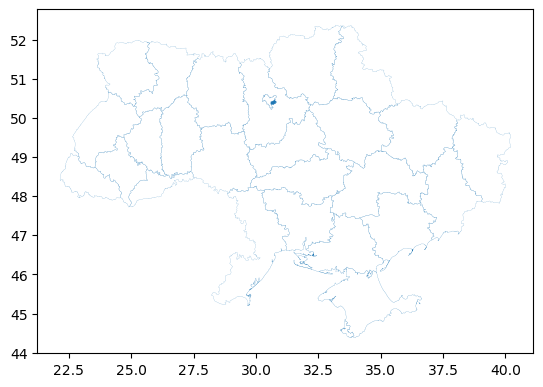

In [12]:
import numpy as np
import matplotlib.pyplot as plt
fig, ax = plt.subplots()
gdf[gdf.index.str.startswith('UA')].boundary.plot(ax=ax, linewidth=0.1)
gdf[gdf.index.str.len() != 5].plot(ax=ax)

# Wrap up

In [13]:
timer.summary()
timer.save()

Timer: import_admin
Total: 472.60s

  Read file.................................................     1.52s      1.53s cpu (  0.3%)
  Get latitude and longitude at WGS84 centroid..............     0.59s      0.53s cpu (  0.1%)
  Get centroids.............................................     3.48s      3.41s cpu (  0.7%)
  Get poles of inaccessibility..............................    71.64s     70.70s cpu ( 15.2%)
  Save as parquet...........................................     4.03s      3.67s cpu (  0.9%)
  Simplify coverage.........................................   148.41s    146.58s cpu ( 31.4%)
  Save simplified coverage as geoparquet....................     0.17s      0.17s cpu (  0.0%)
  Read file.................................................     1.70s      1.67s cpu (  0.4%)
  Get latitude and longitude at WGS84 centroid..............     0.43s      0.42s cpu (  0.1%)
  Get centroids.............................................     4.18s      4.11s cpu (  0.9%)
  Get poles of